### Multiple Linear Regression Using Economic_Index Dataset

In [25]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#loading dataset into dataframe

df = pd.read_csv("datasets\\economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#dropping few columns which are not needed

df.drop(['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
#checking for null values in datasets

df.isnull().sum()


interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [7]:
#checking for duplicated rows

df.duplicated().sum()

np.int64(0)

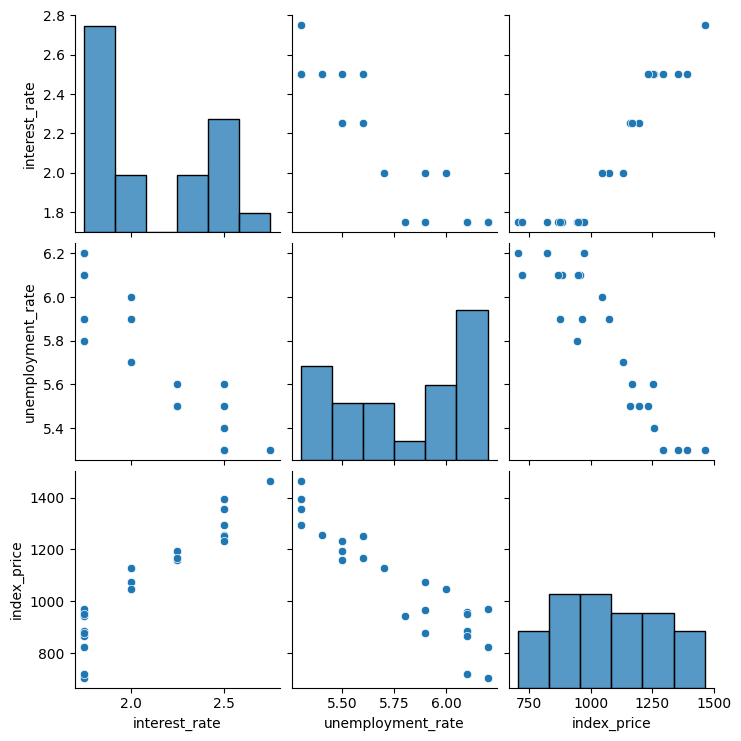

In [8]:
#pair plot of given features

sns.pairplot(df)

In [9]:
#correlation

df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [11]:
#independent and dependent features

x = df[['interest_rate', 'unemployment_rate']]
y = df['index_price']

In [13]:
#splitting into train and test datasets/

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(18, 2)
(6, 2)
(18,)
(6,)


In [15]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [19]:
#training linear regression model

regressor = LinearRegression()
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [38]:
#intercept and coef value

coefficient = regressor.coef_
intercept = regressor.intercept_

print(f"Intercept : {intercept}\nCoefficient: {coefficient}")


Intercept : 1053.4444444444443
Coefficient: [  88.27275507 -116.25716066]


In [22]:
#checking cross validation score

val_score = cross_val_score(estimator=regressor, X=x_train, y=y_train, scoring="neg_mean_squared_error", cv=3)
val_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [23]:
#mean val score

np.mean(val_score)

np.float64(-5914.828180162388)

In [24]:
#performance metrics calculations

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}\nMean Absolute Error: {mae}")

Mean Squared Error: 5793.762887712569
Mean Absolute Error: 59.935781523235484


In [26]:
#r_sqaured and adjusted r_squared values

score = r2_score(y_test, y_pred)
adjusted_r_score =  1-((1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

print(f"R Squared Error: {score}\nAdjusted R Squared Error: {adjusted_r_score}")

R Squared Error: 0.8278978091457145
Adjusted R Squared Error: 0.7131630152428576


##### Assumptions to consider our model is performing well on dataset

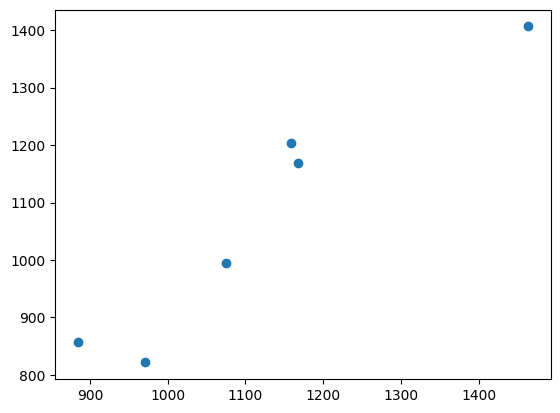

In [29]:
#scatter plot between y_test and y_pred

plt.scatter(y_test, y_pred)

In [31]:
#calculating residual

residual = y_test - y_pred
residual

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

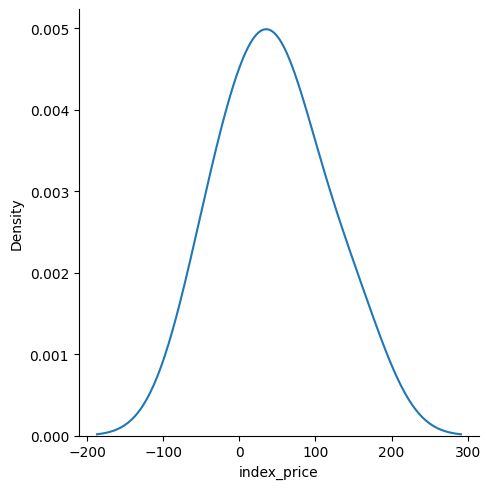

In [34]:
#plotting residuals with displot

sns.displot(residual, kind='kde')

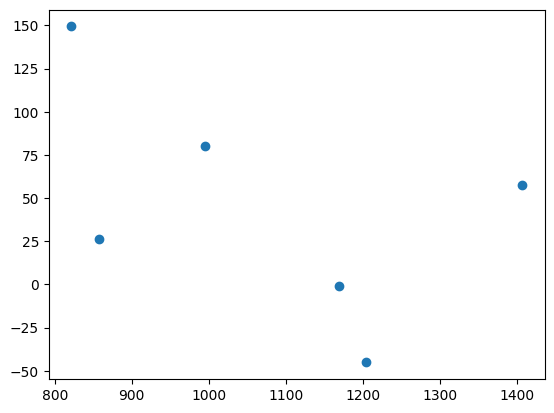

In [35]:
#scatter plot between y_pred and residuals

plt.scatter(y_pred, residual)

##### Using OLS Method:

In [37]:
import statsmodels.api as sm

model = sm.OLS(y_train, x_train).fit()

model.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 06 May 2026   Prob (F-statistic):                       0.754
Time:                        03:23:16   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""